# Import Packages

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                           confusion_matrix,
                           precision_recall_curve,
                           average_precision_score)


# Load SCADA Dataset

In [10]:
# Load data
data = pd.read_csv('wedowind.csv')
data.drop('Unnamed: 0', axis=1, inplace=True)

In [11]:
# Preprocessing
data['timestamp'] = pd.to_datetime(data['timestamp'])
data['hour'] = data['timestamp'].dt.hour


In [12]:
# Remove rows with non-positive power AND rotor speed
data = data[data['rotor_speed'] > 0]

In [13]:
print("Fault class distribution:\n", data["errorcode"].value_counts())  # Assuming 'errorcode' is the target

Fault class distribution:
 errorcode
0    455509
1     59659
Name: count, dtype: int64


# Pre-processing

In [14]:
# Create targets
data['failure'] = (data['errorcode'] != 0).astype(int)
data['time_to_failure'] = data.groupby('plant_name')['failure'].transform(
    lambda x: x[::-1].cumsum()[::-1].shift(-24).fillna(0))

In [15]:
# Advanced feature engineering
def create_features(df):
    # Rolling statistics
    for col in ['wind_speed', 'power', 'generator_temperature']:
        df[f'{col}_rolling_avg_6h'] = df.groupby('plant_name')[col].transform(
            lambda x: x.rolling(6, min_periods=1).mean())
        df[f'{col}_rolling_std_6h'] = df.groupby('plant_name')[col].transform(
            lambda x: x.rolling(6, min_periods=1).std())

    # Equipment stress indicators
    df['power_per_wind'] = df['power'] / (df['wind_speed'] + 0.001)
    df['temp_power_ratio'] = df['generator_temperature'] / (df['power'] + 1)
    return df

data = create_features(data)

In [16]:
# Prepare final features
features = data.drop(['timestamp', 'plant_name', 'errorcode', 'failure', 'time_to_failure'], axis=1)
features.fillna(features.median(), inplace=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    features,
    data['failure'],
    test_size=0.3,
    random_state=42,
    stratify=data['failure']
)

# ➕ Add SMOTE here
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Original class distribution:", np.bincount(y_train))
print("Resampled class distribution:", np.bincount(y_train_resampled))

Original class distribution: [318856  41761]
Resampled class distribution: [318856 318856]


#  Feature Selection

In [17]:
# XGBoost Classifier
model = xgb.XGBClassifier(
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    n_estimators=300
)

In [18]:
model.fit(
    X_train_resampled,
    y_train_resampled,
    eval_set=[(X_test, y_test)],
    verbose=False
)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [19]:
# Optimal threshold finding
precision, recall, thresholds = precision_recall_curve(y_test, model.predict_proba(X_test)[:,1])
f1_scores = 2*(precision*recall)/(precision+recall)
optimal_threshold = thresholds[np.argmax(f1_scores)]


              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98    136653
     Failure       0.88      0.86      0.87     17898

    accuracy                           0.97    154551
   macro avg       0.93      0.92      0.93    154551
weighted avg       0.97      0.97      0.97    154551



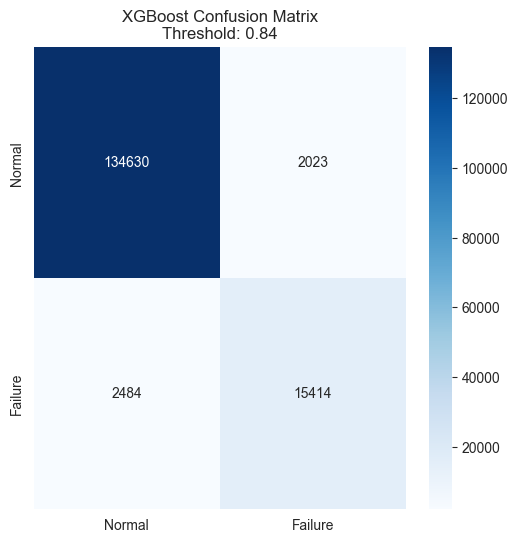

In [20]:
# Evaluation
y_pred = (model.predict_proba(X_test)[:,1] >= optimal_threshold).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Failure']))

# Confusion Matrix
plt.figure(figsize=(6,6))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Failure'],
            yticklabels=['Normal', 'Failure'])
plt.title('XGBoost Confusion Matrix\nThreshold: %.2f' % optimal_threshold)
plt.show()

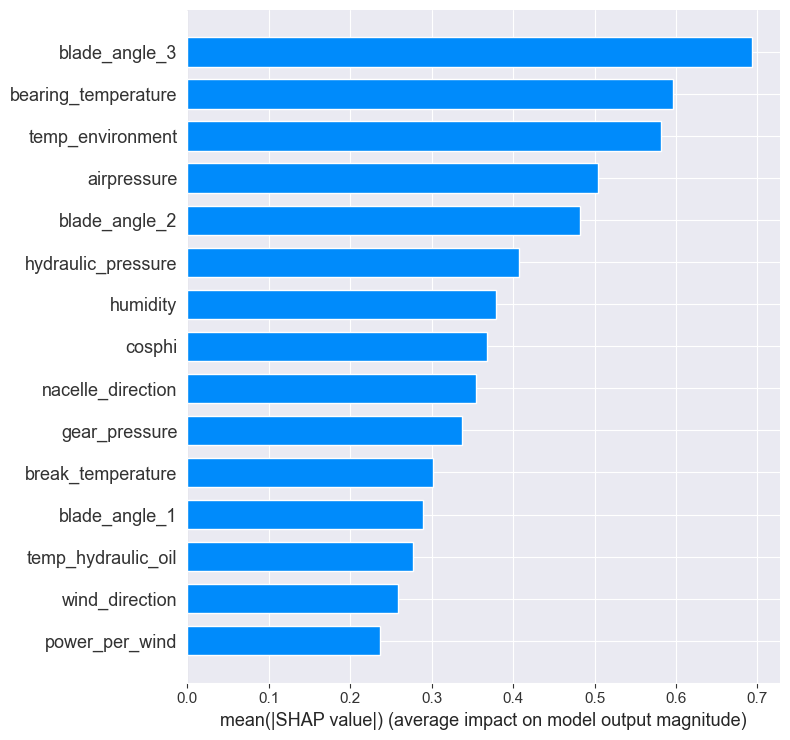

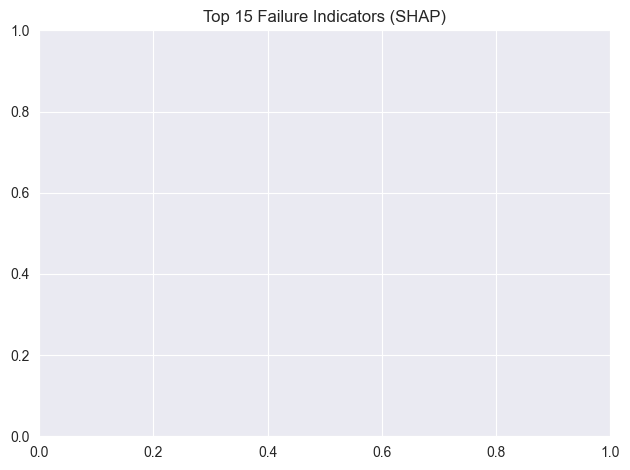

In [21]:
# SHAP Analysis
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15)
plt.title('Top 15 Failure Indicators (SHAP)')
plt.tight_layout()
plt.show()

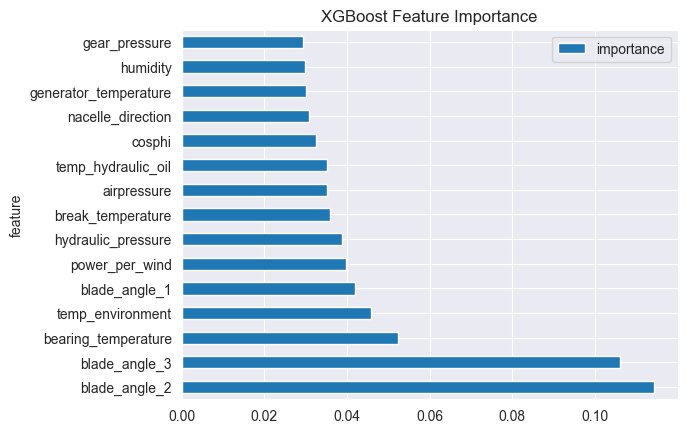

In [22]:

# Feature Importance
pd.DataFrame({
    'feature': features.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(15).plot.barh(x='feature', y='importance')
plt.title('XGBoost Feature Importance')
plt.show()

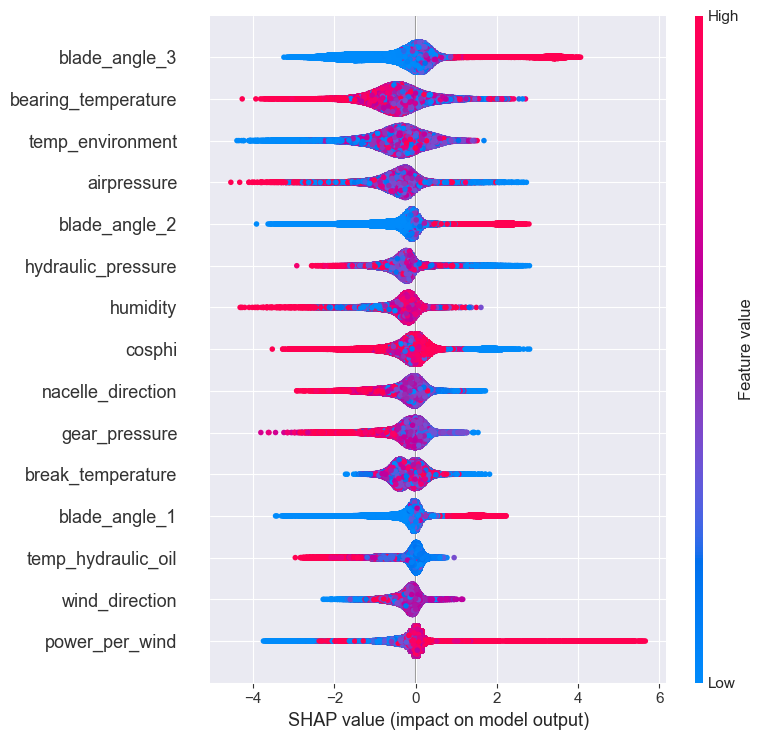

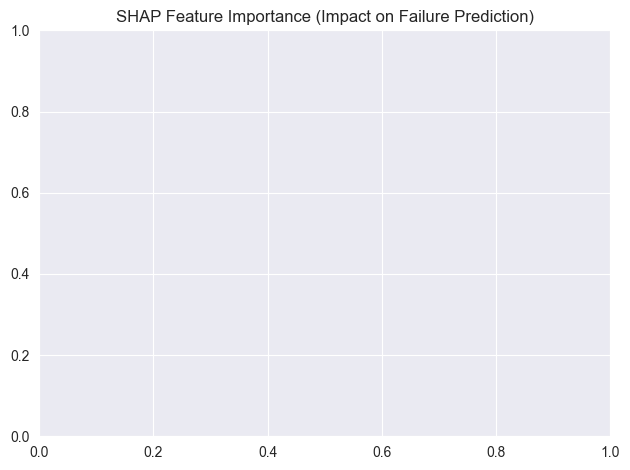

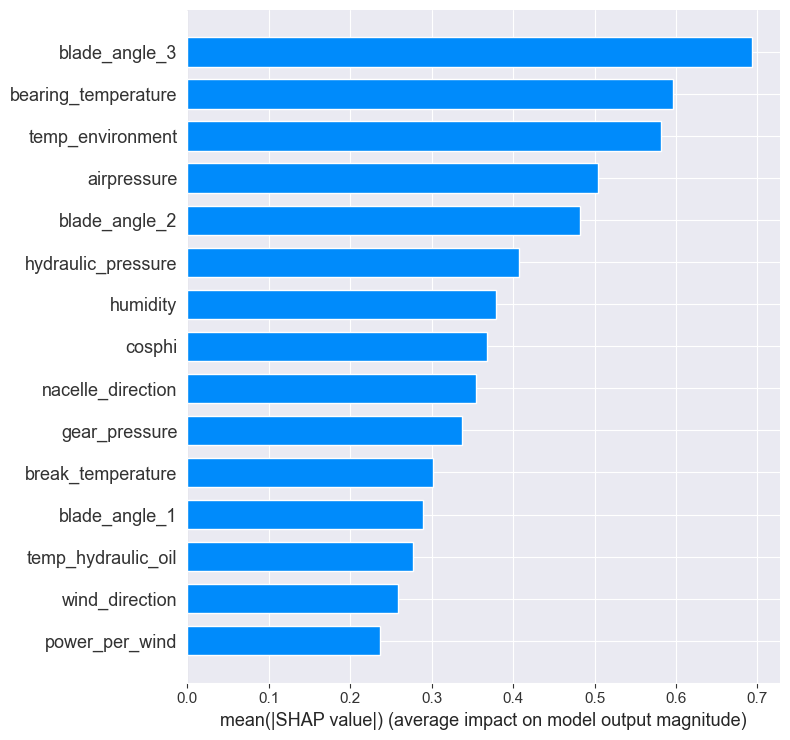

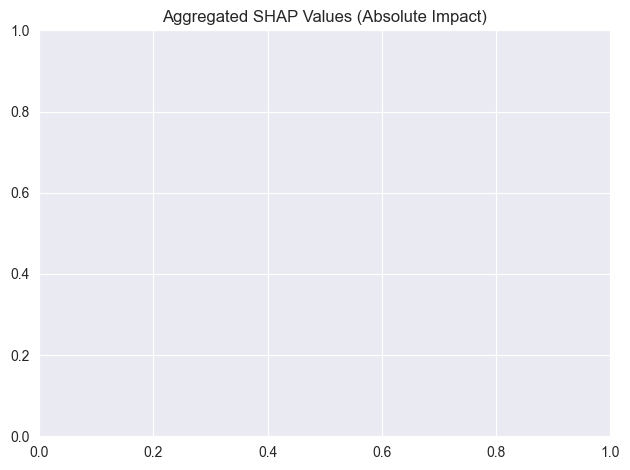

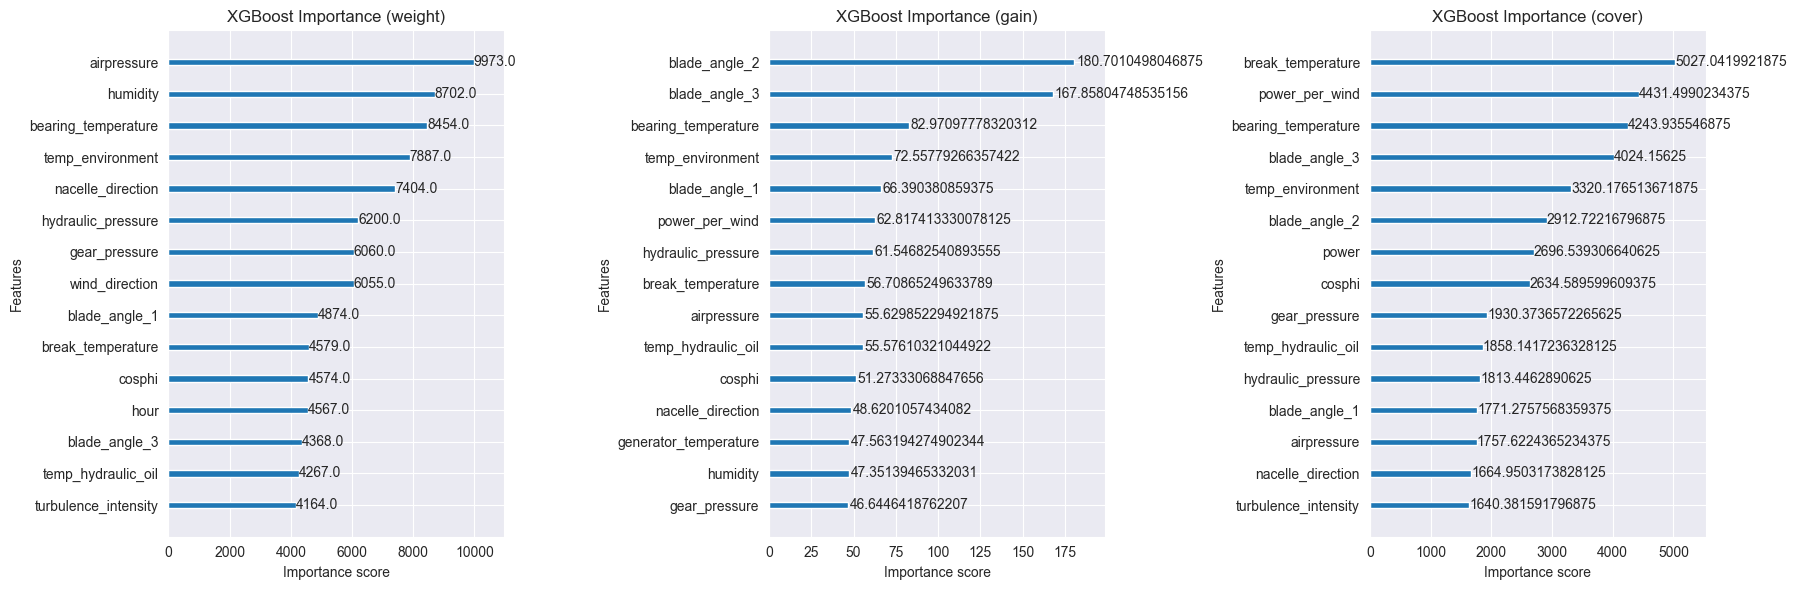

<Figure size 1000x600 with 0 Axes>

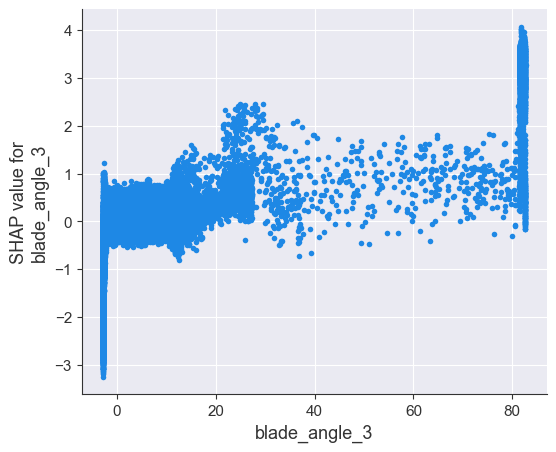

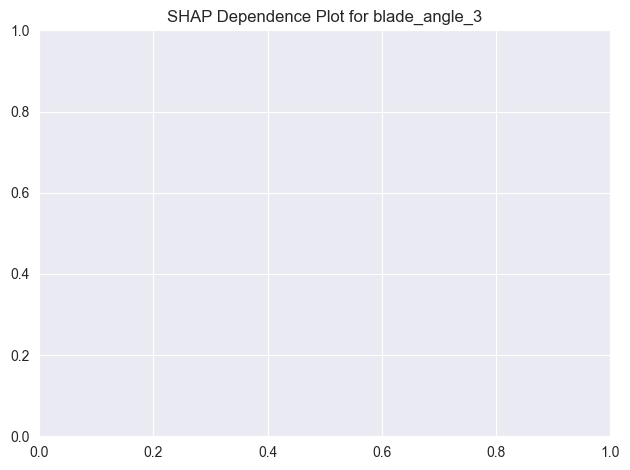

<Figure size 1000x600 with 0 Axes>

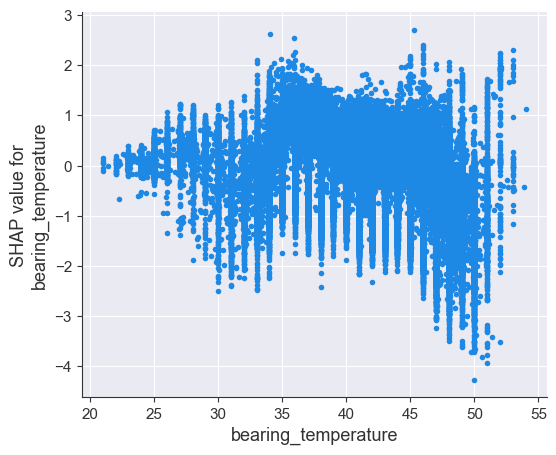

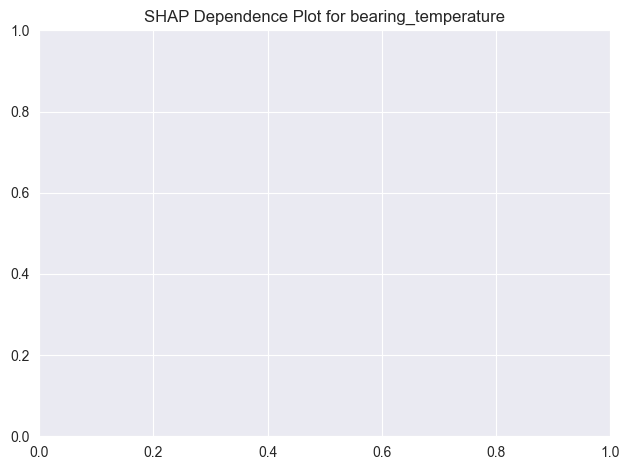

<Figure size 1000x600 with 0 Axes>

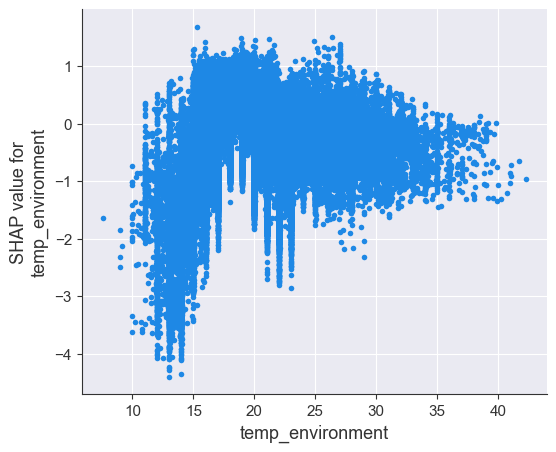

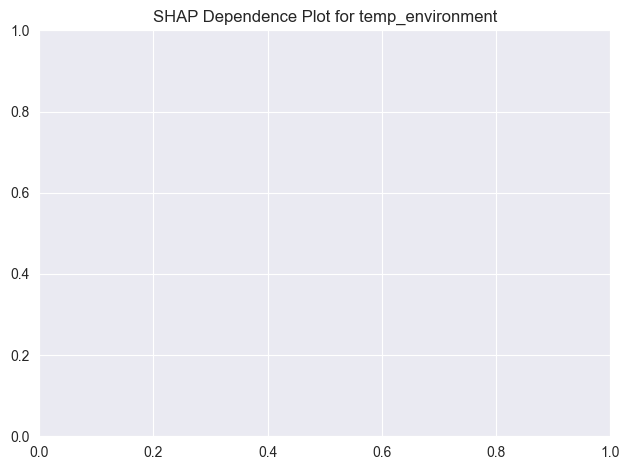


Top 10 Features by Importance:
            Feature  SHAP_Value  XGB_Score
      blade_angle_3    0.693054   0.106142
bearing_temperature    0.596113   0.052465
   temp_environment    0.581435   0.045881
        airpressure    0.504080   0.035177
      blade_angle_2    0.481928   0.114263
 hydraulic_pressure    0.407120   0.038918


In [23]:
# 1. SHAP Summary Plot (Global Importance)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="dot", max_display=15)
plt.title("SHAP Feature Importance (Impact on Failure Prediction)")
plt.tight_layout()
plt.show()

# 2. SHAP Bar Plot (Aggregated Magnitudes)
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15)
plt.title("Aggregated SHAP Values (Absolute Impact)")
plt.tight_layout()
plt.show()

# 3. XGBoost Built-in Feature Importance
importance_types = ['weight', 'gain', 'cover']  # Different importance metrics

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, imp_type in enumerate(importance_types):
    xgb.plot_importance(model, importance_type=imp_type, ax=axes[i], max_num_features=15)
    axes[i].set_title(f'XGBoost Importance ({imp_type})')
plt.tight_layout()
plt.show()

# 4. SHAP Dependence Plots for Top 3 Features
top_features = np.abs(shap_values).mean(axis=0).argsort()[-3:][::-1]

for feat_idx in top_features:
    feature_name = X_test.columns[feat_idx]
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(
        ind=feat_idx,
        shap_values=shap_values,
        features=X_test,
        display_features=X_test,
        interaction_index=None
    )
    plt.title(f'SHAP Dependence Plot for {feature_name}')
    plt.tight_layout()
    plt.show()

# 5. Tabular Feature Importance Comparison
# Create comparison dataframe
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP_Value': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_Value', ascending=False).head(10)

xgb_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'XGB_Score': model.feature_importances_
}).sort_values('XGB_Score', ascending=False).head(10)

# Merge and print
importance_df = shap_importance.merge(xgb_importance, on='Feature')
print("\nTop 10 Features by Importance:")
print(importance_df.to_string(index=False))


# Supervised Learning

In [24]:
# 1. Enhanced Feature Selection using SHAP and Correlation Analysis
top_n_features = 15  # Increased from 10 to capture more temporal patterns

# Get SHAP-based important features
shap_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'SHAP_Value': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_Value', ascending=False)

# Add temporal features that might be important
temporal_features = ['hour', 'month']
selected_features = list(set(shap_importance.head(top_n_features)['Feature'].tolist() + temporal_features))

In [25]:
print(selected_features)

['airpressure', 'break_temperature', 'month', 'cosphi', 'nacelle_direction', 'humidity', 'temp_environment', 'power_per_wind', 'blade_angle_3', 'blade_angle_1', 'blade_angle_2', 'temp_hydraulic_oil', 'hydraulic_pressure', 'wind_direction', 'bearing_temperature', 'hour', 'gear_pressure']


In [26]:
def create_ttf_feature(group):
    """Create Time-to-Failure feature following paper's exact methodology"""
    group = group.sort_values('timestamp')
    group['ttf'] = 0.0

    failure_indices = group.index[group['failure'] == 1].tolist()

    # Calculate time until next failure for each point
    for i in range(len(group)):
        current_time = group.iloc[i]['timestamp']
        future_failures = group[(group['timestamp'] > current_time) & (group['failure'] == 1)]

        if not future_failures.empty:
            next_failure_time = future_failures.iloc[0]['timestamp']
            ttf_hours = (next_failure_time - current_time).total_seconds() / 3600
            group.loc[group.index[i], 'ttf'] = ttf_hours
        else:
            # No future failures in this turbine's data
            group.loc[group.index[i], 'ttf'] = np.nan

    return group

In [27]:
# 1. Apply TTF creation to each turbine separately
data_ttf = data.groupby('plant_name', group_keys=False).apply(create_ttf_feature)

C:\Users\usuario\AppData\Local\Temp\ipykernel_22132\2209835155.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_ttf = data.groupby('plant_name', group_keys=False).apply(create_ttf_feature)


In [28]:
# 2. Clean and filter data as specified in paper
data_ttf = data_ttf.dropna(subset=['ttf'])  # Remove unknown TTF
data_ttf = data_ttf[(data_ttf['ttf'] <= 15) & (data_ttf['ttf'] > 0)]  # Last 15h before failure
data_ttf = data_ttf[data_ttf['failure'] == 0]  # Remove actual failure points


In [29]:
# 3. Prepare features and target
features = [col for col in selected_features if col in data_ttf.columns]
X = data_ttf[features]
y = data_ttf['ttf']
groups = data_ttf['plant_name']

In [30]:
from sklearn.model_selection import LeaveOneGroupOut
# 4. Leave-One-Out Cross Validation by turbine
logo = LeaveOneGroupOut()
mae_results = {}
predictions = {}

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

for train_index, test_index in logo.split(X, y, groups):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    turbine_id = groups.iloc[test_index[0]]

    # Train Random Forest with paper's parameters
    rfr = RandomForestRegressor(n_estimators=100, max_depth=None,
                              max_features='sqrt', random_state=42, n_jobs=-1)
    rfr.fit(X_train, y_train)

    # Make predictions and store results
    y_pred = rfr.predict(X_test)
    mae_results[turbine_id] = mean_absolute_error(y_test, y_pred)

    if turbine_id in [109, 120]:  # Store specific turbines for plotting
        predictions[turbine_id] = {
            'actual': y_test,
            'predicted': y_pred,
            'timestamps': data_ttf.iloc[test_index]['timestamp']
        }



MAE Results for All Turbines (hours):
Turbine ID | MAE (h)
--------------------
      109 | 2.85
      114 | 2.32
      115 | 2.85
      116 | 2.99
      120 | 2.59


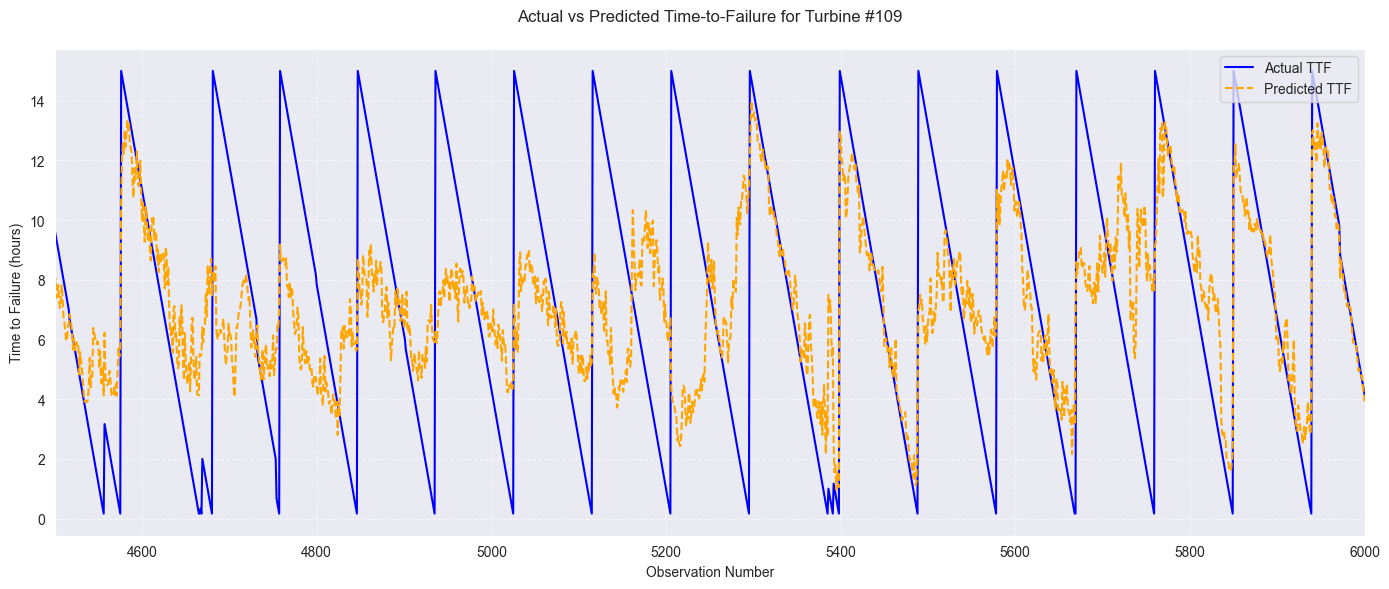

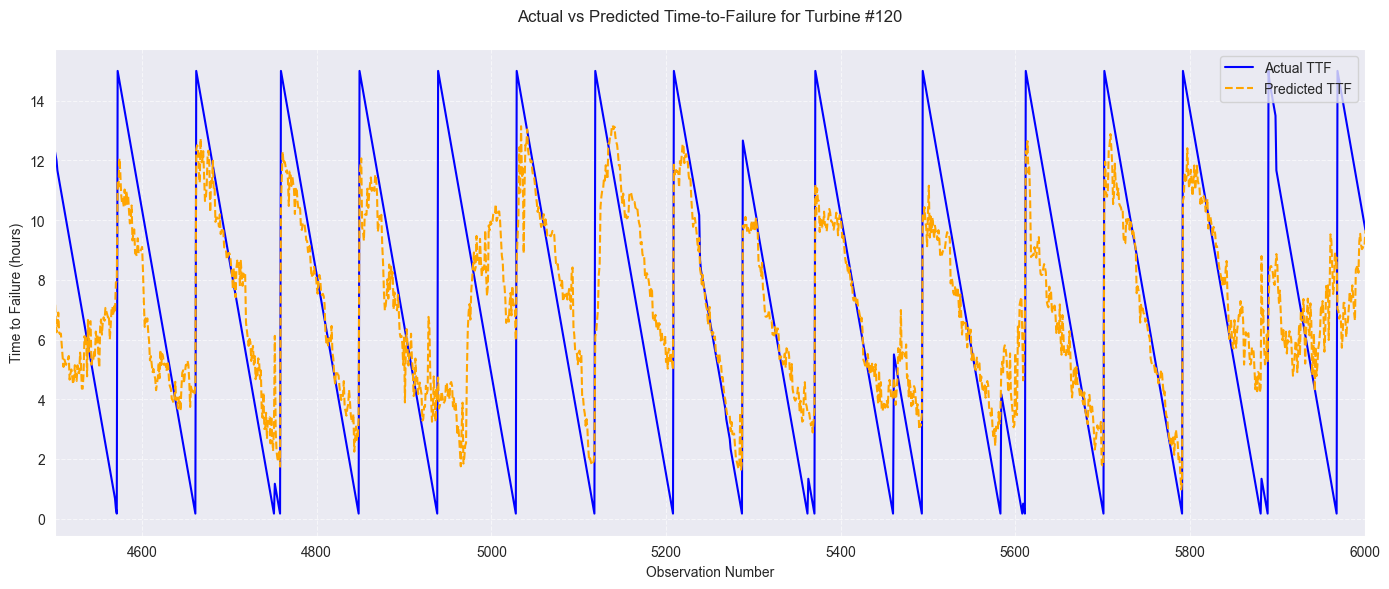

In [32]:
# 5. Output MAE results
print("\nMAE Results for All Turbines (hours):")
print("Turbine ID | MAE (h)")
print("--------------------")
for turbine_id, mae in sorted(mae_results.items()):
    print(f"{turbine_id:9} | {mae:.2f}")

# 6. Plot results for specific turbines
def plot_turbine_results(turbine_id, predictions):
    if turbine_id not in predictions:
        print(f"No data for turbine {turbine_id}")
        return

    data = predictions[turbine_id]
    obs_numbers = np.arange(len(data['timestamps']))

    plt.figure(figsize=(14, 6))
    plt.plot(obs_numbers, data['actual'], label='Actual TTF', color='blue', linewidth=1.5)
    plt.plot(obs_numbers, data['predicted'], label='Predicted TTF', color='orange', linestyle='--', linewidth=1.5)



    plt.title(f"Actual vs Predicted Time-to-Failure for Turbine #{turbine_id}", pad=20)
    plt.xlabel("Observation Number")
    plt.ylabel("Time to Failure (hours)")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)

    if len(obs_numbers) > 5700:
        plt.xlim(4500, 6000)

    plt.tight_layout()
    plt.show()

# Generate plots
plot_turbine_results(109, predictions)
plot_turbine_results(120, predictions)